# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [2]:
# GPU 확인
!nvidia-smi

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Wed Sep  9 13:03:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### **데이터셋 준비 (MNIST dataset)**

In [3]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.11MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [4]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # z = mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

encode는 입력 이미지에서 잠재변수 분포의 평균과 로그 분산을 계산합니다. 먼저 fc1과 ReLU를 통해 특징을 추출한 뒤 fc21과 fc22를 각각 통과시켜 mu와 logvar를 구합니다.
reparameterize는 계산된 평균과 분산을 이용해 잠재변수 z를 샘플링합니다. 표준편차를 std = torch.exp(0.5 * logvar)로 계산하고 표준정규분포에서 추출한 eps를 사용해 z = mu + eps + std로 계산합니다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [5]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

elbo_loss 함수는 VAE의 전체 손실을 계산하는 함수입니다. 먼저 x를 784차원 벡터로 변환하고 recon_x와 원본 x 사이의 차이를 BCE로 계산합니다. 이 값을 통해 입력 이미지를 얼마나 잘 복원했는지 알 수 있습니다. 그다음 mu와 logvar를 사용해 잠재분포와 표준정규분포 사이의 차이를 KLD로 계산합니다. KL Divergence는 잠재공간이 정규분포에 가깝게 형성되도록 정규화하는 역할을 합니다. 마지막에 BCE와 KLD를 더해 최종 손실인 total_loss를 구합니다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.

KD Divergence는 인코더가 만든 잠재분포 q(z|x)가 표준정규분포에 가까워지도록 정규화하는 역할을 한다. KL 항이 없으면 각 입력 이미지가 서로 무관하게 흩어진 잠재공간을 만들 수 있어 새로운 z를 샘플링해도 의미 있는 이미지를 생성하기 힘들다. KL Divergence를 포함하면 잠재공간이 연속적이고 규칙적으로 구성되어 표준정규분포에서 샘플링한 값을 디코더에 넣어도 자연스러운 이미지를 생성할 수 있다.


In [6]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3212 | Val Loss: 1.0349
Epoch [2/15] Train Loss: 0.9662 | Val Loss: 0.9306
Epoch [3/15] Train Loss: 0.9035 | Val Loss: 0.8930
Epoch [4/15] Train Loss: 0.8787 | Val Loss: 0.8751
Epoch [5/15] Train Loss: 0.8643 | Val Loss: 0.8639
Epoch [6/15] Train Loss: 0.8547 | Val Loss: 0.8561
Epoch [7/15] Train Loss: 0.8475 | Val Loss: 0.8512
Epoch [8/15] Train Loss: 0.8420 | Val Loss: 0.8453
Epoch [9/15] Train Loss: 0.8383 | Val Loss: 0.8413
Epoch [10/15] Train Loss: 0.8343 | Val Loss: 0.8392
Epoch [11/15] Train Loss: 0.8315 | Val Loss: 0.8369
Epoch [12/15] Train Loss: 0.8289 | Val Loss: 0.8340
Epoch [13/15] Train Loss: 0.8267 | Val Loss: 0.8324
Epoch [14/15] Train Loss: 0.8246 | Val Loss: 0.8317
Epoch [15/15] Train Loss: 0.8229 | Val Loss: 0.8296


**VAE sampling 시각화**

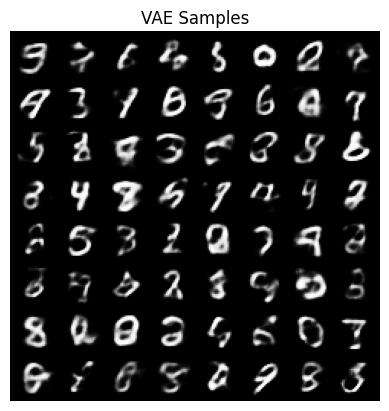

In [7]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [9]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [10]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Generator.forward는 잠재벡터 z를 입력받아 28x28 크기의 MNIST 이미지를 생성한다. 먼저 ConTranspose2d를 이용해 (B, 20, 1, 1) 형태의 잠재벡터를 점차 큰 feature map으로 확장한다. 각 중간층에서는 Batch Normalization과 ReLU 활성화 함수를 사용해 학습을 안정화한다. 마지막에는 tconv4를 통과시킨 후 Tanh를 적용하여 생성 이미지의 픽셀값을 [-1, 1] 범위로 변환한다.

In [11]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Discriminator는 입력 이미지가 실제 이미지인지 Generator가 만든 가짜 이미지인지 판별한다. Conv2d 층을 사용해 이미지의 크기를 점차 줄이면서 특징을 추출하고, BatchNorm과 LeakyReLU를 통해 학습을 안정화한다. conv4와 sigmoid를 통해 입력 이미지가 실제일 확률을 마지막으로 계산하고 이후에 view와 squeeze를 사용해 출력값을 배치별 하나의 확률값 형태로 변환한다. 출력값이 1에 가까우면 실제 이미지, 0에 가까우면 가짜 이미지로 판단한다.

In [12]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [13]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7963 | Loss G: 1.7069
Epoch [2/15] Loss D: 0.8920 | Loss G: 1.4874
Epoch [3/15] Loss D: 0.9799 | Loss G: 1.3490
Epoch [4/15] Loss D: 1.0066 | Loss G: 1.3170
Epoch [5/15] Loss D: 1.0334 | Loss G: 1.2974
Epoch [6/15] Loss D: 1.0171 | Loss G: 1.3301
Epoch [7/15] Loss D: 1.0170 | Loss G: 1.3428
Epoch [8/15] Loss D: 1.0269 | Loss G: 1.3352
Epoch [9/15] Loss D: 0.9999 | Loss G: 1.3916
Epoch [10/15] Loss D: 1.0004 | Loss G: 1.3977
Epoch [11/15] Loss D: 0.9974 | Loss G: 1.4181
Epoch [12/15] Loss D: 0.9872 | Loss G: 1.4269
Epoch [13/15] Loss D: 0.9712 | Loss G: 1.4617
Epoch [14/15] Loss D: 0.9677 | Loss G: 1.4759
Epoch [15/15] Loss D: 0.9757 | Loss G: 1.4547


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

이 코드는 Discriminator와 Generator를 번갈아 학습하는 GAN의 학습 과정이다. 먼저 실제 이미지에는 1, Generator가 만든 이미지에는 0을 정답으로 설정하고 Discriminator를 학습한다. fake_img.detach()는 Discriminator를 학습할 때 Generator로 gradient가 전달되지 않도록 한다. 그다음 Generator를 학습할 때는 가짜 이미지의 정답을 real로 설정한다. Generator는 Discriminator가 가짜 이미지를 진짜 이미지라고 판단하도록 학습되기 때문이다. 마지막으로 backward()와 step()을 통해 각각의 네트워크 가중치를 업데이트하고, epoch이 끝나면 평균 loss를 계산한다.

**DCGAN Sampling 시각화**

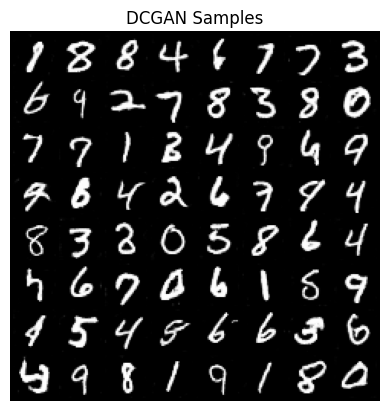

In [14]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

VAE는 입력 이미지를 잠재공간으로 압축한 뒤 다시 복원하는 구조이며, Reconstruction Loss와 KL Divergence를 사용한다. 픽셀 단위의 평균적인 복원을 목표로 하기 때문에 여러 가능한 이미지의 특징이 평균화되어 결과가 흐릿해질 수 있다. 반면 DCGAN은 Generator와 Discriminator가 서로 경쟁하는 방식으로 학습한다. Generator는 Discriminator를 속이기 위해 실제 이미지의 세부적인 특징과 질감을 더 잘 표현하려고 하므로 선명한 이미지를 생성할 수 있다. 따라서 VAE는 학습이 비교적 안정적이고 잠재공간을 해석하기 쉽지만 이미지가 흐릿할 수 있고, DCGAN은 더 선명한 이미지를 생성하는 대신 학습이 불안정하거나 mode collapse가 발생할 수 있다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

Discriminator가 너무 빠르게 강해지면 실제 이미지와 가짜 이미지를 거의 완벽하게 구분하게 된다. 이 경우 Generator가 받는 gradient가 매우 작아져 Vanishing Gradient가 발생하고, Generator가 제대로 학습되지 않을 수 있다. 반대로 Generator가 특정 패턴의 이미지만 반복해서 생성하면 Discriminator를 일시적으로 속일 수 있지만, 다양한 이미지 유형을 생성하지 못하는 Mode Collapse가 발생한다. 따라서 GAN은 Generator와 Discriminator가 적절한 균형을 유지하도록 학습하는 것이 중요하다.

## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [16]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

forward_diffusion 함수는 원본 이미지 x0에 timestep t에 해당하는 양의 Gaussian noise를 추가하여 noisy image x_t를 만드는 함수이다. x_t = sqrt_ac * x0 + sqrt_omac * noise에서 sqrt_ac는 원본 이미지의 영향력을 조절하고, sqrt_omac는 noise의 영향력을 조절한다. timestep이 작을 때는 원본 이미지가 많이 남아 있고, timestep이 커질수록 noise의 비중이 증가하여 이미지가 점점 노이즈에 가까워진다. 함수는 생성된 x_t와 실제로 추가한 noise를 함께 반환한다. 이때 실제 noise는 나중에 모델이 예측한 noise와 비교하는 정답으로 사용된다.

**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

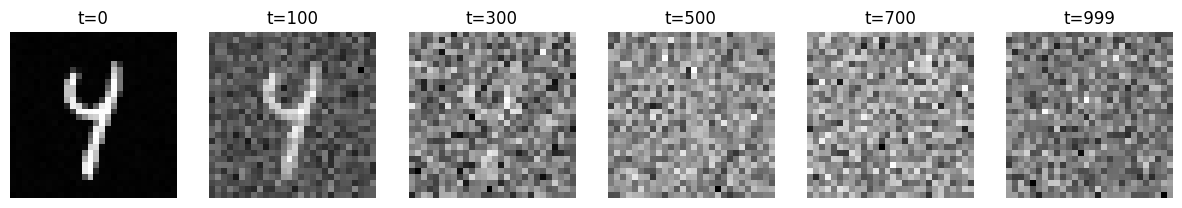

In [17]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [18]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

timestep t를 sinusoidal embedding과 MLP를 통해 벡터로 변환한 뒤, time_proj를 사용해 bottleneck feature의 채널 수인 256에 맞춘다. unsqueeze를 사용해 t_proj의 크기를 (B, 256, 1, 1)로 만들면 PyTorch의 broadcasting에 의해 h3의 모든 공간 위치에 timestep 정보가 더해진다. 이를 통해 네트워크가 현재 이미지에 얼마나 많은 noise가 포함되어 있는지 알 수 있다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [19]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

ddpm_loss는 DDPM의 학습 손실을 계산하는 함수이다. 먼저 각 이미지마다 timestep t를 무작위로 선택하고, forward_diffusion을 이용해 원본 이미지에 noise를 추가한다. 그다음 모델은 noisy image x_t와 timestep t를 입력받아 실제로 추가된 noise를 예측하고 마지막으로 모델이 예측한 noise와 실제 noise 사이의 평균제곱오차를 계산한다. loss를 최소화하면서 모델은 다양한 timestep에서 noise를 제거하는 방법을 학습하게 된더.

## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

원본 이미지 x₀를 직접 예측하게 하면 timestep마다 달라지는 복잡한 이미지 복원 문제를 직접 학습해야 한다. 반면 noise ε는 항상 표준정규분포에서 생성되므로 예측 대상이 단순하고 일관적이다. 또한 x_t와 timestep t가 주어지면 이미지에 실제로 추가된 noise를 명확하게 계산할 수 있어 모델은 실제 noise와 예측 noise 사이의 MSE Loss를 최소화하면서 안정적으로 학습할 수 있다. 이렇게 학습된 noise 예측 모델을 reverse process에 사용하면 noise가 섞인 이미지에서 noise를 조금씩 제거하여 원본 이미지에 가까운 결과를 생성할 수 있다.


In [20]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [21]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

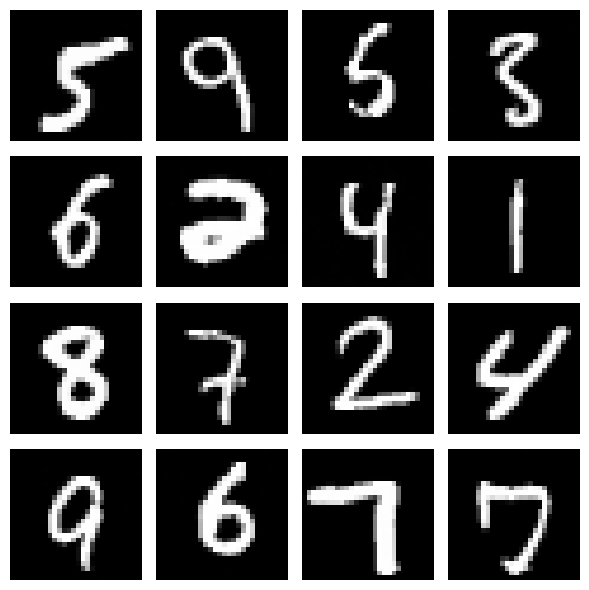

In [22]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

DDPM의 생성 결과가 VAE나 GAN보다 일관적이지 않은 이유는 여러 단계의 denoising 과정을 거치기 때문이다. DDPM은 매 timestep마다 현재 이미지에서 noise를 조금씩 제거하는데, 각 단계의 예측이 완벽하지 않으면 작은 오차가 다음 단계로 누적될 수 있다. 또한 생성은 무작위 noise에서 시작하므로 실행할 때마다 초기 조건이 달라진다. 학습이 충분하지 않거나 모델의 크기가 작으면 noise를 정확히 제거하지 못해 어떤 이미지는 숫자를 잘 생성하지만, 어떤 이미지는 악필처럼 보이거나 숫자를 제대로 만들지 못할 수 있다.
특히 이번 실습의 MNIST DDPM은 제한된 데이터와 학습 시간으로 만들어진 사전학습 모델이므로 모든 샘플에서 완벽한 결과를 보장하지 않는다. 따라서 DDPM은 생성 과정이 확률적이고 반복적인 denoising에 의존하기 때문에 결과의 다양성은 높지만, 샘플마다 품질 차이가 발생할 수 있다.


## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

VAE는 Reconstruction Loss와 KL Divergence를 사용하기 때문에 학습이 비교적 안정적이다. 하지만 픽셀을 평균적으로 복원하는 특성 때문에 이미지가 흐릿해질 수 있다.
GAN은 Generator와 Discriminator가 경쟁하며 학습하므로 선명하고 사실적인 이미지를 생성할 수 있지만 두 모델의 균형에 민감하고, 한 가지 패턴만 반복하는 mode collapse가 발생할 수 있어 학습 안정성이 낮다.
Diffusion은 noise 예측을 MSE Loss로 학습하기 때문에 GAN보다 안정적이고 다양한 이미지를 생성할 수 있다. 생성 품질도 높지만 여러 timestep에서 반복적으로 denoising해야 하므로 추론 속도가 가장 느리다.



## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [23]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [24]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

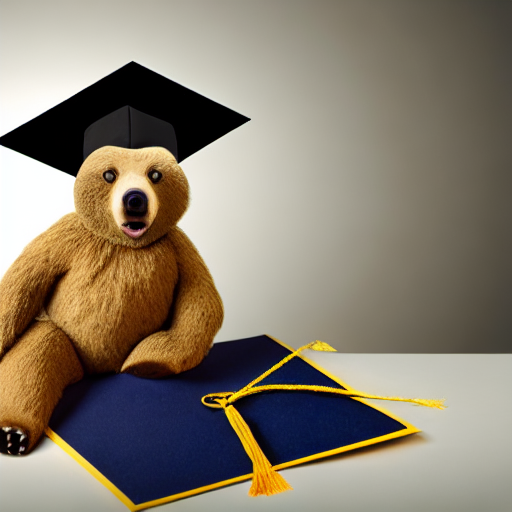

In [25]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

num_inference_steps는 초기 noise에서 최종 이미지까지 denoising을 수행하는 횟수다. 값을 크게 하면 noise를 더 여러 단계에 걸쳐 제거하므로 이미지의 세부 묘사와 품질이 좋아질 수 있지만 실행 시간이 길어진다. 반대로 값을 작게 하면 이미지를 빠르게 생성할 수 있지만, noise 제거가 충분하지 않아 이미지 품질이나 프롬프트 반영 정도가 떨어질 수 있다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

guidance_scale=1.0에서는 prompt의 영향이 약해 이미지가 자연스럽지만, 졸업모를 쓴 곰이라는 조건이 명확하게 반영되지 않을 수 있다. guidance_scale=15.0에서는 prompt와의 정합성이 높아져 곰이나 졸업모 같은 특징이 더 뚜렷하게 나타날 수 있다. 그러나 값이 너무 높으면 색상이 과도하게 강조되거나 이미지가 부자연스러워지는 artifact가 발생할 수 있다.
따라서 guidance_scale은 적당히 높일수록 prompt 반영력이 좋아지지만, 지나치게 높이면 이미지의 자연스러움이 떨어질 수 있다.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

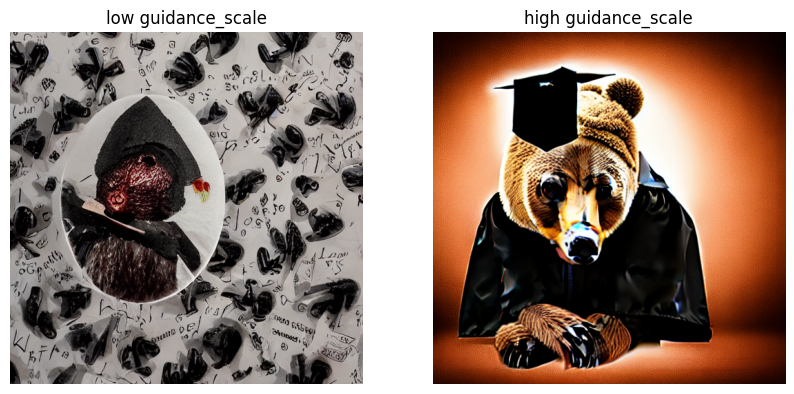

In [26]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

guidance_scale은 Classifier-Free Guidance의 강도를 조절하는 값으로, 입력 prompt를 이미지 생성에 얼마나 강하게 반영할지 결정한다. guidance_scale=1.0에서는 prompt의 영향이 약해 이미지가 비교적 자연스럽지만, “졸업모를 쓴 곰”이라는 조건이 덜 반영될 수 있다. 반대로 guidance_scale=15.0에서는 prompt의 특징이 강하게 반영되어 원하는 형태가 더 뚜렷해질 수 있다. 그러나 값이 너무 높으면 색상이 과장되거나 이미지가 부자연스러워지는 artifact가 생길 수 있다.


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

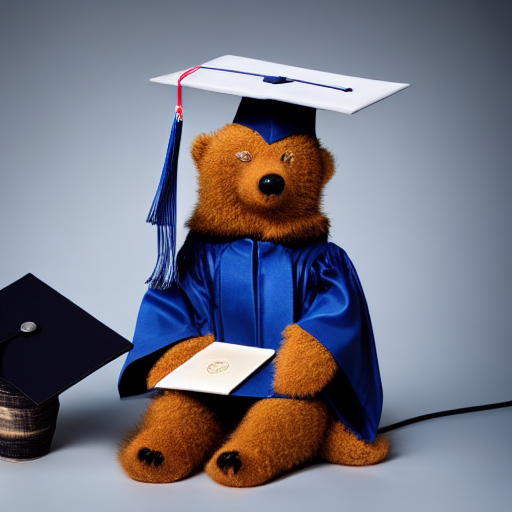

In [27]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

DDPM은 reverse process에서 많은 timestep을 순차적으로 거치며 noise를 조금씩 제거한다. 따라서 높은 품질의 이미지를 만들 수 있지만, 많은 step이 필요해 생성 속도가 느리다. DDIM은 DDPM과 동일하게 학습된 noise prediction 모델을 사용하면서도 timestep을 일부 건너뛰는 방식으로 denoising 경로를 구성할 수 있다. 이전 단계의 결과를 활용해 더 효율적으로 다음 이미지를 예측하기 때문에 적은 step으로도 그럴듯한 이미지를 생성할 수 있다. 따라서 DDIM은 DDPM보다 추론 속도가 빠르지만, step 수를 지나치게 줄이면 이미지 품질이 떨어질 수 있다.


## **🙋 [Hugging Face] Question 3**

실행 후 사용한 모델 3개와 결과를 본인의 출력에 맞게 추가하세요. 예: text-to-image 모델, image-to-image 모델, image classification 모델을 각각 호출하고 입력·출력·느낀 점을 기록합니다.
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 이번 과제에서는 PyTorch 빈칸 코드의 문법과 VAE·GAN·Diffusion 개념을 점검하는 데 AI를 활용했습니다. 최종 코드는 직접 실행해 shape과 loss 계산이 맞는지 확인해야 합니다.

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: AI가 제시한 답은 실행 결과와 공식 문서를 대조해 확인한 뒤 사용했습니다. 실제로 실행한 결과와 다른 사례가 있었다면 본인의 출력과 수정 내용을 여기에 구체적으로 적습니다.

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 이 대화의 실제 기록을 그대로 붙여넣습니다. 제출 전 본인 대화 내역으로 교체하세요.


수고하셨습니다 ☺️